# **Project Dự báo Nợ xấu của Khách hàng**

## Mục tiêu:
Khám phá và phân tích dữ liệu tín dụng thẻ của khách hàng

Tìm hiểu về nhân khẩu học, hạn mức tín dụng và lịch sử trả nợ

Đưa ra insights giúp cảnh báo rủi ro và giảm tỷ lệ nợ xấu

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

In [8]:
df = pd.read_csv('../data/[GenZ] UCI_Credit_Card.csv')
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


### **Data Cleaning**

In [9]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

-> Data sạch không có missing values do số lượng records ở các cột đều bằng nhau 

-> Sẵn sàng để phân tích EDA

In [11]:
print(f"Số lượng dòng trước khi loại bỏ trùng lặp: {len(df)}")
df.drop_duplicates(inplace=True)
print(f"Số lượng dòng sau khi loại bỏ trùng lặp: {len(df)}")

Số lượng dòng trước khi loại bỏ trùng lặp: 30000
Số lượng dòng sau khi loại bỏ trùng lặp: 30000


In [12]:
df['SEX'].unique()
df['SEX'].value_counts()

SEX
2    18112
1    11888
Name: count, dtype: int64

In [13]:
df['MARRIAGE'].unique()
df['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

In [14]:
df['EDUCATION'].unique()
df['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [15]:
df['PAY_0'].unique()
df['PAY_0'].value_counts()

PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: count, dtype: int64

In [16]:
print(df['PAY_2'].unique())
print(df['PAY_2'].value_counts())
print(df['PAY_3'].unique())
print(df['PAY_3'].value_counts())
print(df['PAY_4'].unique())
print(df['PAY_4'].value_counts())
print(df['PAY_5'].unique())
print(df['PAY_5'].value_counts())
print(df['PAY_6'].unique())
print(df['PAY_6'].value_counts())

[ 2  0 -1 -2  3  5  7  4  1  6  8]
PAY_2
 0    15730
-1     6050
 2     3927
-2     3782
 3      326
 4       99
 1       28
 5       25
 7       20
 6       12
 8        1
Name: count, dtype: int64
[-1  0  2 -2  3  4  6  7  1  5  8]
PAY_3
 0    15764
-1     5938
-2     4085
 2     3819
 3      240
 4       76
 7       27
 6       23
 5       21
 1        4
 8        3
Name: count, dtype: int64
[-1  0 -2  2  3  4  5  7  6  1  8]
PAY_4
 0    16455
-1     5687
-2     4348
 2     3159
 3      180
 4       69
 7       58
 5       35
 6        5
 1        2
 8        2
Name: count, dtype: int64
[-2  0 -1  2  3  5  4  7  8  6]
PAY_5
 0    16947
-1     5539
-2     4546
 2     2626
 3      178
 4       84
 7       58
 5       17
 6        4
 8        1
Name: count, dtype: int64
[-2  2  0 -1  3  6  4  7  8  5]
PAY_6
 0    16286
-1     5740
-2     4895
 2     2766
 3      184
 4       49
 7       46
 6       19
 5       13
 8        2
Name: count, dtype: int64


Nếu bạn để nguyên các con số này dưới dạng số (Continuous/Numeric) rồi đưa vào các thuật toán như Logistic Regression, OLS, Support Vector Machines (SVM), hay Neural Networks:

Thuật toán coi đây là một khoảng cách đều (Ordinal / Interval):

Máy tính sẽ hiểu khoảng cách từ -2 lên -1 (tăng 1 đơn vị) có giá trị y hệt khoảng cách từ 1 lên 2 (tăng 1 đơn vị).

Thực tế ngân hàng: Khách hàng từ 1 (trễ 1 tháng) chuyển sang 2 (trễ 2 tháng) là rủi ro nhảy vọt lên gấp mấy lần (bắt đầu dính nợ xấu). Còn khách hàng từ -2 (không tiêu) sang -1 (tiêu rồi trả hết) đều là nhóm khách hàng siêu an toàn.

**Khoảng cách vô lý giữa -1 và 0:**

Từ -1 (trả sạch nợ) sang 0 (trả tối thiểu) chỉ chênh 1 đơn vị. Nhưng từ 0 sang 1 (trở thành con nợ trễ hạn) cũng chênh 1 đơn vị. Bản chất hành vi giữa "người trả đúng hạn" (0) và "người vi phạm hợp đồng" (1) khác nhau một trời một vực, nhưng số 0 và 1 làm thuật toán tưởng chúng "suýt soát giống nhau".

**Sự nhập nhằng về mặt định nghĩa giữa -2, -1 và 0**
Dù được tách ra thành 3 mã khác nhau, nhưng xét dưới góc độ Nguy cơ Vỡ nợ (Default Risk):Người -2 (không xài thẻ) 
$\rightarrow$ Không có nguy cơ vỡ nợ.Người -1 (trả hết tiền) 
$\rightarrow$ Không có nguy cơ vỡ nợ.Người 0 (trả đủ mức tối thiểu) 
$\rightarrow$ Ngân hàng thu được tiền lãi, đúng hạn, không có nguy cơ vỡ nợ ngay lập tức.Cả 3 nhóm này đều thuộc về chung một bản chất: Khách hàng tuân thủ nghĩa vụ thanh toán (Non-Delinquent / Good Customers).

Gộp -2, -1, 0 lại thành mã 0 (Nhóm trả đúng hạn/Không trễ nợ) sẽ giúp loại bỏ bớt Noise không cần thiết cho mô hình, giúp máy tập trung phân biệt nhóm này với nhóm thật sự trễ nợ (1, 2, 3...).

**Vấn đề Mất cân bằng dữ liệu ở các nhóm số dương (Imbalance & Sparse Data)**

Khi soi vào tần suất của các số dương:
Nhóm 0 hoặc -1: Có hàng chục nghìn khách hàng.
Nhóm 5, 6, 7, 8 (Trễ nợ 5-8 tháng): Số lượng khách hàng cực kỳ ít (chỉ vài chục người).

Nếu giữ nguyên từng con số từ 1 đến 8, mô hình sẽ bị Overfitting (Quá khớp) ở các nhóm ít dữ liệu như 7, 8. Khi bin các số này lại (ví dụ: gộp tất cả $\ge 2$ thành nhóm "Trễ nợ nghiêm trọng"), bạn sẽ tạo ra một nhóm dữ liệu đủ lớn và có ý nghĩa thống kê để mô hình học tập chính xác.

In [17]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for col in pay_cols:
  conditions = [
      df[col] <= 0,
      df[col] == 1,
      df[col] >= 2,
  ]
  choices = [0, 1, 2]

  df[f'{col}_GROUP'] = np.select(conditions, choices, default=0)

print(pd.crosstab(df['PAY_0'], df['PAY_0_GROUP']))

PAY_0_GROUP      0     1     2
PAY_0                         
-2            2759     0     0
-1            5686     0     0
 0           14737     0     0
 1               0  3688     0
 2               0     0  2667
 3               0     0   322
 4               0     0    76
 5               0     0    26
 6               0     0    11
 7               0     0     9
 8               0     0    19


In [18]:
target_col = 'default.payment.next.month'
summary = pd.DataFrame(
    {
        'Mã số': [0, 1],
        'Số lượng': df[target_col].value_counts().values,
        'Tỷ lệ %': (
            df[target_col].value_counts(normalize=True) * 100
        ).round(2).values,
    },
    index=['Không vỡ nợ (0)', 'Vỡ nợ (1)'],
)

summary.index.name = 'Trạng thái'
print(summary)

                 Mã số  Số lượng  Tỷ lệ %
Trạng thái                               
Không vỡ nợ (0)      0     23364    77.88
Vỡ nợ (1)            1      6636    22.12


**Dữ liệu bị mất cân bằng (Imbalanced Data)**: Tỷ lệ giữa lớp đa số (0 - Không vỡ nợ) và lớp yếu tố rủi ro (1 - Vỡ nợ) rơi vào khoảng 3.5 : 1.

Mức độ mất cân bằng: Đây là mức độ mất cân bằng trung bình (Moderate Imbalance). Tỷ lệ 22% vỡ nợ thực tế là khá hợp lý và phản ánh đúng thực trạng rủi ro tín dụng thẻ trong ngành ngân hàng (không bị quá hiếm như các bài toán phát hiện gian lận giao dịch/fraud detection vốn chỉ chiếm < 1%).

Hoặc điều chỉnh tham số trong mô hình (ví dụ: gán class_weight='balanced' trong Logistic Regression, Random Forest, XGBoost).

Không dùng Accuracy (Độ chính xác): Chỉ số Accuracy sẽ bị vô hiệu hóa / đánh lừa trong bài toán này.

`Thay vào đó:`

Recall (Độ gợi nhớ): Đo lường xem mô hình bắt được bao nhiêu % trong số 6,636 người vỡ nợ thật. Trong ngân hàng, chỉ số này cực kỳ quan trọng vì thà bắt nhầm còn hơn bỏ sót nợ xấu.

Precision & F1-Score: Để đảm bảo sự cân bằng, không báo động giả quá nhiều.

ROC-AUC & PR-AUC: Thước đo tổng quát nhất để đánh giá khả năng phân loại rủi ro của mô hình trên dữ liệu mất cân bằng.

### **Continuous Variables Analysis**

In [19]:
cols = (
    ['LIMIT_BAL', 'AGE']
    + [f'BILL_AMT{i}' for i in range(1, 7)]
    + [f'PAY_AMT{i}' for i in range(1, 7)]
)

results = []
for col in cols:
  s = df[col]
  q75, q25 = np.percentile(s, [75, 25])
  iqr = q75 - q25
  results.append({
      'Variable': col,
      'Mean': s.mean(),
      'Median': s.median(),
      'Std': s.std(),
      'Min': s.min(),
      'Max': s.max(),
      'IQR': iqr,
  })

stats_df = pd.DataFrame(results)
print(stats_df)

     Variable           Mean    Median            Std       Min        Max  \
0   LIMIT_BAL  167484.322667  140000.0  129747.661567   10000.0  1000000.0   
1         AGE      35.485500      34.0       9.217904      21.0       79.0   
2   BILL_AMT1   51223.330900   22381.5   73635.860576 -165580.0   964511.0   
3   BILL_AMT2   49179.075167   21200.0   71173.768783  -69777.0   983931.0   
4   BILL_AMT3   47013.154800   20088.5   69349.387427 -157264.0  1664089.0   
5   BILL_AMT4   43262.948967   19052.0   64332.856134 -170000.0   891586.0   
6   BILL_AMT5   40311.400967   18104.5   60797.155770  -81334.0   927171.0   
7   BILL_AMT6   38871.760400   17071.0   59554.107537 -339603.0   961664.0   
8    PAY_AMT1    5663.580500    2100.0   16563.280354       0.0   873552.0   
9    PAY_AMT2    5921.163500    2009.0   23040.870402       0.0  1684259.0   
10   PAY_AMT3    5225.681500    1800.0   17606.961470       0.0   896040.0   
11   PAY_AMT4    4826.076867    1500.0   15666.159744       0.0 

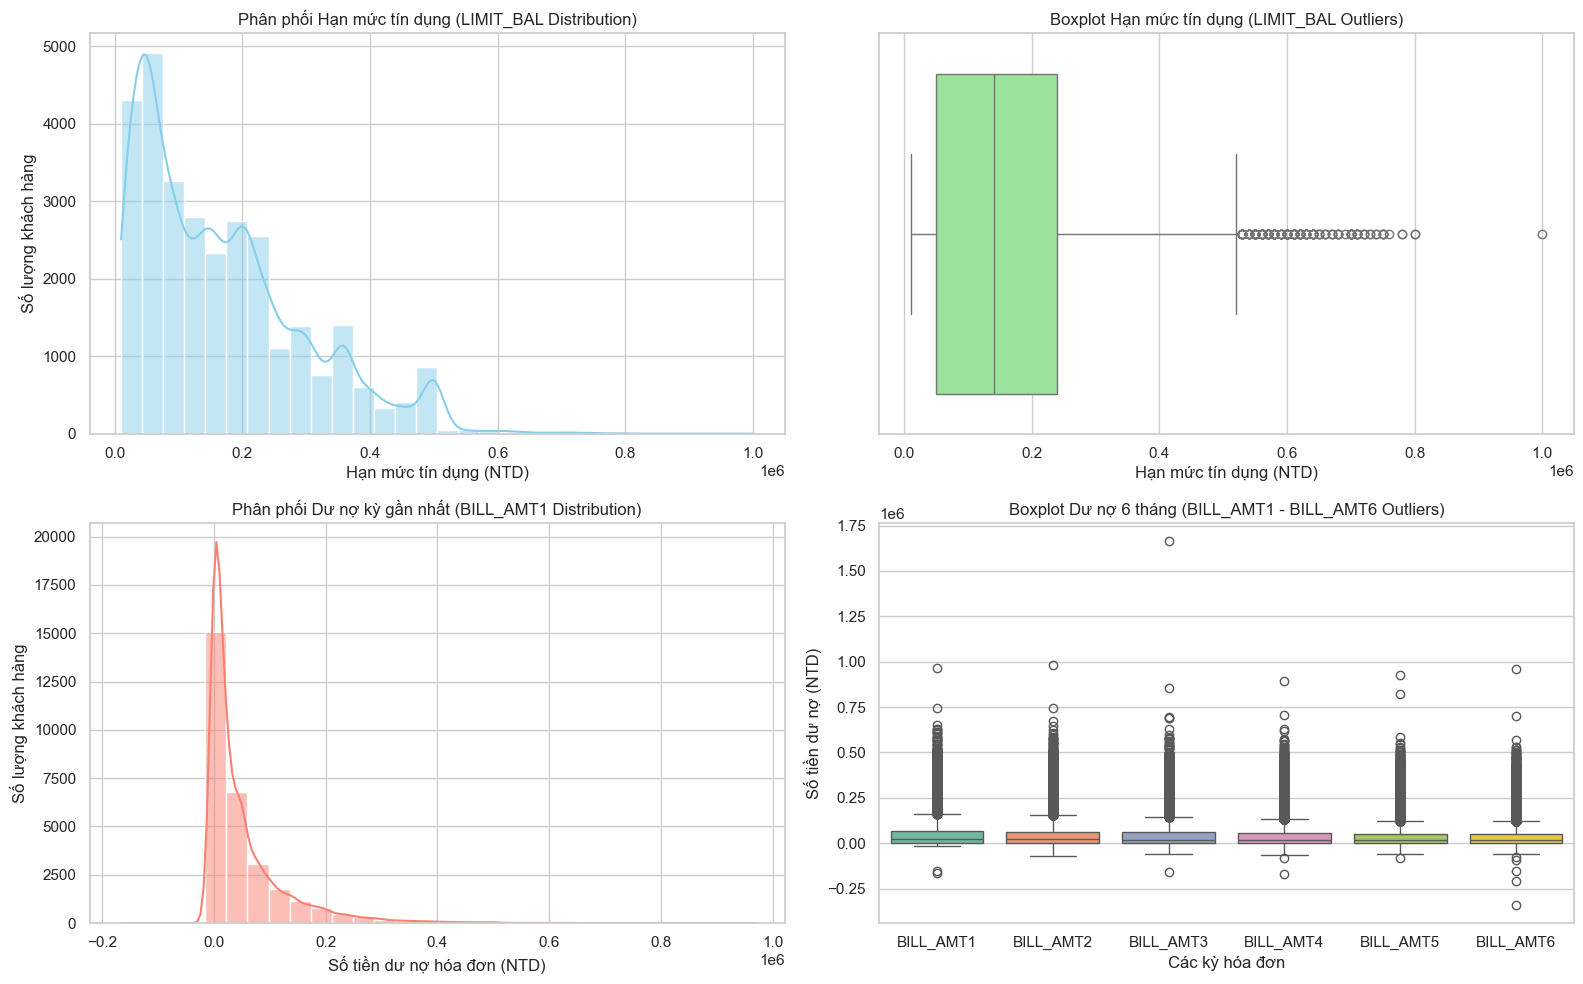

In [20]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(
    data=df,
    x='LIMIT_BAL',
    kde=True,
    color='skyblue',
    ax=axes[0, 0],
    bins=30,
)
axes[0, 0].set_title(
    'Phân phối Hạn mức tín dụng (LIMIT_BAL Distribution)', fontsize=12
)
axes[0, 0].set_xlabel('Hạn mức tín dụng (NTD)')
axes[0, 0].set_ylabel('Số lượng khách hàng')

sns.boxplot(x=df['LIMIT_BAL'], color='lightgreen', ax=axes[0, 1])
axes[0, 1].set_title(
    'Boxplot Hạn mức tín dụng (LIMIT_BAL Outliers)', fontsize=12
)
axes[0, 1].set_xlabel('Hạn mức tín dụng (NTD)')

sns.histplot(
    data=df,
    x='BILL_AMT1',
    kde=True,
    color='salmon',
    ax=axes[1, 0],
    bins=30,
)
axes[1, 0].set_title(
    'Phân phối Dư nợ kỳ gần nhất (BILL_AMT1 Distribution)', fontsize=12
)
axes[1, 0].set_xlabel('Số tiền dư nợ hóa đơn (NTD)')
axes[1, 0].set_ylabel('Số lượng khách hàng')

bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
sns.boxplot(data=df[bill_cols], palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title(
    'Boxplot Dư nợ 6 tháng (BILL_AMT1 - BILL_AMT6 Outliers)', fontsize=12
)
axes[1, 1].set_xlabel('Các kỳ hóa đơn')
axes[1, 1].set_ylabel('Số tiền dư nợ (NTD)')

plt.tight_layout()
plt.show()

**LIMIT_BAL distribution hist:**

Hình dạng phân phối: Dữ liệu bị lệch phải nặng (Right-skewed).

Xu hướng chính: Phần lớn khách hàng tập trung ở mức hạn mức nhỏ và trung bình, đỉnh cao nhất rơi vào khoảng 50,000 đến 100,000 NTD. Số lượng khách hàng giảm dần khi hạn mức tăng lên.

Điểm bất thường (Multimodal Peaks): Có các "đỉnh nhỏ" nhô lên ở các mốc tròn số như 200,000 NTD, 360,000 NTD, và 500,000 NTD.

Ý nghĩa nghiệp vụ: Đây là kết quả của chính sách phê duyệt tín dụng phân tầng theo bậc (Tiered Credit Limits) của ngân hàng chứ không phải do khách hàng tự nhiên lựa chọn.

Kết hợp với descriptive statistics thì thấy được có các outliers với giá trị lớn đã kéo Mean lên cao hơn cả Median dù right-skewed khá nặng.

**LIMIT_BAL Outliers boxplot**

Khung trung vị & Tứ phân vị (IQR): 50% số lượng khách hàng nằm trong khoảng hạn mức từ ~$50,000$ đến ~$240,000$ NTD, với giá trị Trung vị (Median) quanh mức 140,000 NTD.

Phát hiện Outliers: Xuất hiện rất nhiều điểm ngoại lệ (các chấm tròn) nằm ở phía bên phải đường ranh giới (Whiskers), bắt đầu từ khoảng > 500,000 NTD kéo dài đến 1,000,000 NTD.

Ý nghĩa nghiệp vụ: Nhóm có hạn mức > 500k là phân khúc khách hàng VIP/cao cấp rất đặc thù. Do đó khi làm Machine Learning, cần cân nhắc việc scaling (chuẩn hóa) dữ liệu để nhóm này không kéo lệch mô hình.

**BILL_AMT1 Distribution Hist**

Hình dạng phân phối: Độ lệch phải cực kỳ nghiêm trọng (Highly Right-skewed) và có độ nhọn rất cao (High Kurtosis) quanh mốc 0.

Tập trung dữ liệu: Đại đa số khách hàng có dư nợ kỳ gần nhất rất thấp (dưới 50,000 NTD) hoặc dư nợ bằng 0.

Mức dư nợ âm (BILL_AMT1 < 0): Xuất hiện một phần đồ thị nằm về phía bên trái mốc 0 (giá trị âm).

Ý nghĩa nghiệp vụ:

Số lượng lớn khách hàng giữ dư nợ ở mức thấp thể hiện thói quen thanh toán khá an toàn của phần lớn người dùng.

Các giá trị dư nợ âm phản ánh trường hợp khách hàng trả thừa tiền hóa đơn hoặc được hoàn tiền/cashback từ kỳ trước

**BILL_AMT1 - BILL_AMT6 Outliers**

Tính ổn định qua thời gian: Mức trung vị (đường gạch ngang giữa các hộp) và khoảng tứ phân vị (IQR) của cả 6 kỳ hóa đơn (BILL_AMT1 đến BILL_AMT6) gần như tương đồng và giữ nguyên qua thời gian (dao động quanh mốc 20,000 NTD).

Outliers dày đặc ở phía cực đại: Cả 6 kỳ đều có một dải chấm đen kéo dài từ 200,000 NTD lên tới gần 1,000,000 NTD, thậm chí ở BILL_AMT3 có cá biệt một kỷ lục lên tới hơn 1.6 triệu NTD.

Outliers ở phía cực tiểu (Dư nợ âm): Xuất hiện ở tất cả các kỳ, đặc biệt là BILL_AMT6 có dư nợ âm xuống tới hơn -300,000 NTD.

Ý nghĩa nghiệp vụ: Mối tương quan về dư nợ giữa các kỳ là cực kỳ cao. Khách hàng có xu hướng duy trì thói quen chi tiêu/nợ nần rất ổn định theo hàng tháng (người tiêu nhiều thì kỳ nào cũng nhiều, người tiêu ít thì kỳ nào cũng ít).

### **Categorical Data Analysis** ( Nhân khẩu học )

SEX_LABEL
Nữ     18112
Nam    11888
Name: count, dtype: int64
EDU_LABEL
Đại học            14030
Thạc sĩ/Tiến sĩ    10585
Phổ thông           4917
Khác                 468
Name: count, dtype: int64
MARRIAGE_LABEL
Độc thân      15964
Đã kết hôn    13659
Khác            377
Name: count, dtype: int64
AGE_GROUP
20-29     9618
30-39    11238
40-49     6464
50-59     2341
60+        339
Name: count, dtype: int64


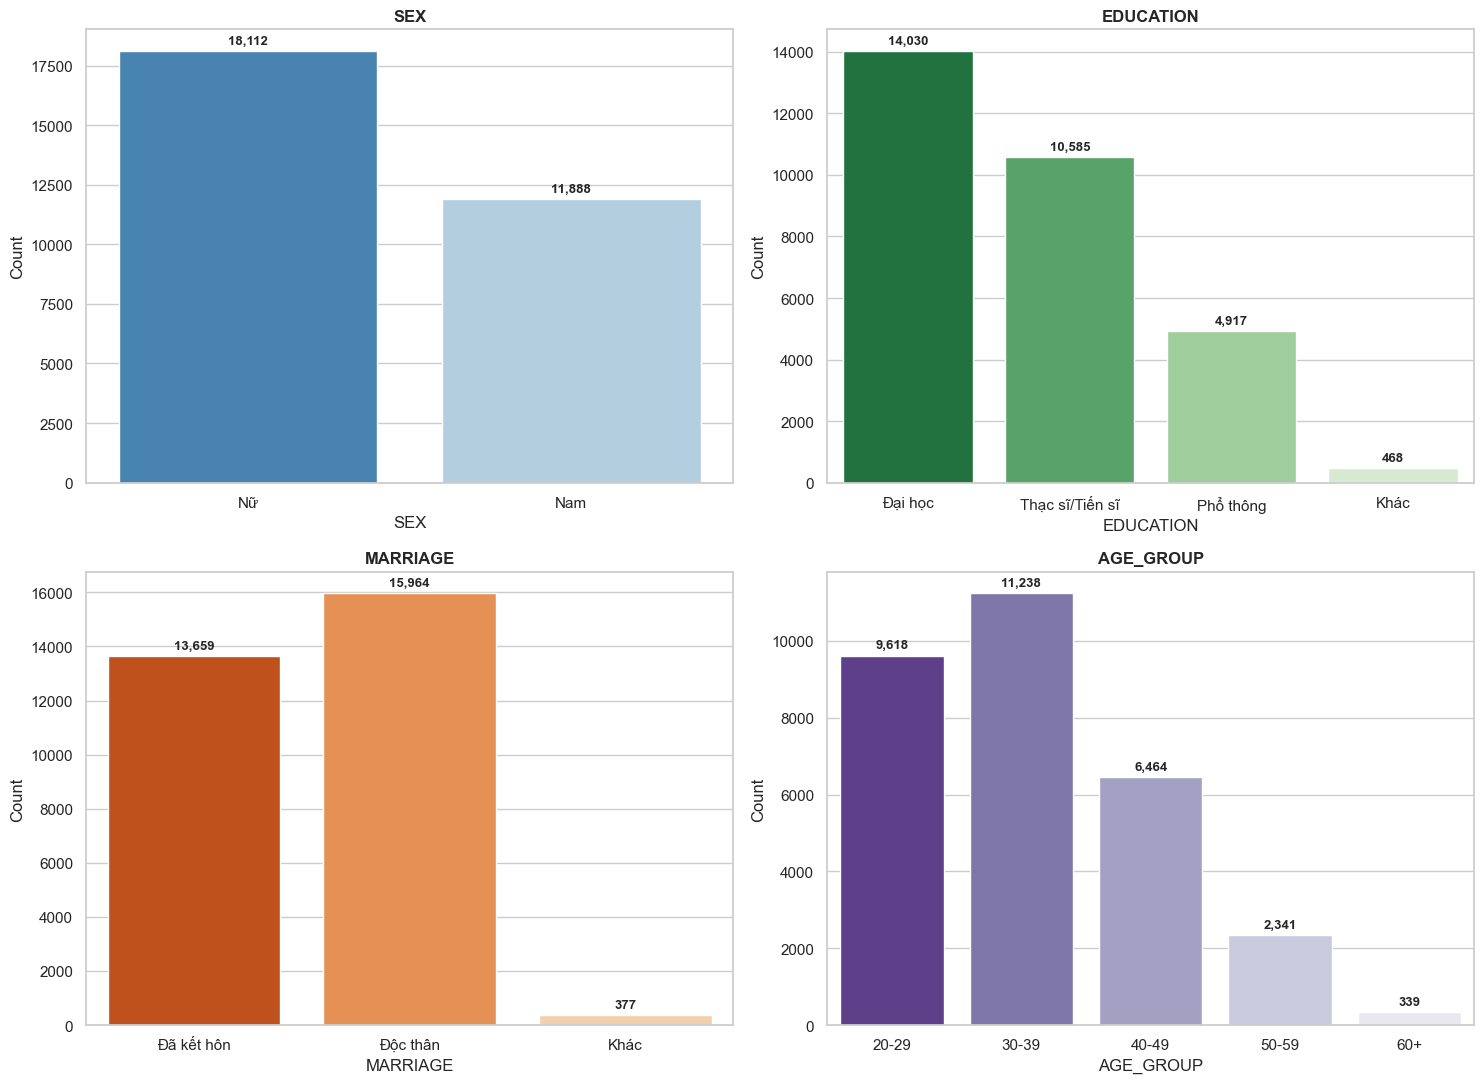

In [21]:
sex_map = {1: 'Nam', 2: 'Nữ'}
edu_map = {
    1: 'Thạc sĩ/Tiến sĩ',
    2: 'Đại học',
    3: 'Phổ thông',
    4: 'Khác',
    0: 'Khác',
    5: 'Khác',
    6: 'Khác',
}
marriage_map = {1: 'Đã kết hôn', 2: 'Độc thân', 3: 'Khác', 0: 'Khác'}

df['SEX_LABEL'] = df['SEX'].map(sex_map)
df['EDU_LABEL'] = df['EDUCATION'].map(edu_map)
df['MARRIAGE_LABEL'] = df['MARRIAGE'].map(marriage_map)

age_bins = [20, 30, 40, 50, 60, 100]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60+']
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=age_bins, labels=age_labels, right=False)

print(df['SEX_LABEL'].value_counts())
print(df['EDU_LABEL'].value_counts())
print(df['MARRIAGE_LABEL'].value_counts())
print(df['AGE_GROUP'].value_counts().sort_index())

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

sns.countplot(
    data=df, x='SEX_LABEL', ax=axes[0, 0], palette='Blues_r', hue='SEX_LABEL'
)
axes[0, 0].set_title('SEX', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('SEX')
axes[0, 0].set_ylabel('Count')

sns.countplot(
    data=df,
    x='EDU_LABEL',
    ax=axes[0, 1],
    palette='Greens_r',
    order=['Đại học', 'Thạc sĩ/Tiến sĩ', 'Phổ thông', 'Khác'],
    hue='EDU_LABEL',
)
axes[0, 1].set_title('EDUCATION', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('EDUCATION')
axes[0, 1].set_ylabel('Count')

sns.countplot(
    data=df,
    x='MARRIAGE_LABEL',
    ax=axes[1, 0],
    palette='Oranges_r',
    hue='MARRIAGE_LABEL',
)
axes[1, 0].set_title('MARRIAGE', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('MARRIAGE')
axes[1, 0].set_ylabel('Count')

sns.countplot(
    data=df,
    x='AGE_GROUP',
    ax=axes[1, 1],
    palette='Purples_r',
    hue='AGE_GROUP',
)
axes[1, 1].set_title('AGE_GROUP', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('AGE_GROUP')
axes[1, 1].set_ylabel('Count')

for ax in axes.flat:
  for p in ax.patches:
    height = int(p.get_height())
    if height > 0:
      ax.annotate(
          f'{height:,}',
          (p.get_x() + p.get_width() / 2.0, height),
          ha='center',
          va='bottom',
          fontsize=9.5,
          fontweight='bold',
          xytext=(0, 3),
          textcoords='offset points',
      )

plt.tight_layout()
plt.show()

Đại đa số khách hàng sở hữu trình độ học vấn cao, trong đó nhóm có bằng Đại học và Sau đại học chiếm hơn 82% tổng tệp dữ liệu.

Nhóm trình độ Phổ thông chỉ chiếm khoảng 16.4%, và nhóm Khác chiếm tỷ trọng rất nhỏ.

Cơ cấu khách hàng tương đối cân bằng giữa nhóm Độc thân và Đã kết hôn, với nhóm Độc thân nhỉnh hơn (~53%).

Nhóm Khác (ly hôn, goá, không xác định) chỉ chiếm tỷ lệ không đáng kể (~1.3%)

Phân phối độ tuổi có dạng lệch phải (Right-skewed) rõ nét.Khách hàng tập trung chủ yếu ở độ tuổi lao động trẻ từ 20 đến 39 tuổi (chiếm tới gần 70% toàn bộ tập dữ liệu).

Trong đó, nhóm 30–39 tuổi chiếm tỷ trọng lớn nhất.Tỷ lệ khách hàng giảm mạnh từ sau 40 tuổi và chỉ có hơn 1% khách hàng thuộc nhóm người cao tuổi ($60+$).

In [22]:
default_rate_sex = round(df.groupby('SEX')['default.payment.next.month'].mean() * 100, 2)
default_rate_sex = default_rate_sex.to_frame(name='Default Rate (%)')
default_rate_sex

,Default Rate (%)
SEX,
1,24.17
2,20.78


Nam giới (1) có tỷ lệ vỡ nợ là 24.17%, cao hơn so với Nữ giới (2) là 20.78% (chênh lệch 3.39%).

Mặc dù khách hàng nữ chiếm số lượng áp đảo trong bộ dữ liệu (~60.4%), nhưng nhóm khách hàng nam lại có xu hướng rủi ro tín dụng cao hơn.

In [23]:
default_rate_edu = round(df.groupby('EDUCATION')['default.payment.next.month'].mean() * 100, 2)
default_rate_edu = default_rate_edu.to_frame(name='Default Rate (%)')
default_rate_edu

,Default Rate (%)
EDUCATION,
0,0.00
1,19.23
2,23.73
3,25.16
4,5.69
5,6.43
6,15.69


In [24]:
default_rate_marriage = round(df.groupby('MARRIAGE')['default.payment.next.month'].mean() * 100, 2)
default_rate_marriage = default_rate_marriage.to_frame(name='Default Rate (%)')
default_rate_marriage

,Default Rate (%)
MARRIAGE,
0,9.26
1,23.47
2,20.93
3,26.01


In [25]:
default_rate_age = round(df.groupby('AGE_GROUP')['default.payment.next.month'].mean() * 100, 2)
default_rate_age = default_rate_age.to_frame(name='Default Rate (%)')
default_rate_age

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11812\1549674469.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_rate_age = round(df.groupby('AGE_GROUP')['default.payment.next.month'].mean() * 100, 2)


,Default Rate (%)
AGE_GROUP,
20-29,22.84
30-39,20.25
40-49,22.97
50-59,24.86
60+,28.32


  LIMIT_GROUP  Tong_KH  So_KH_Vo_No  Default_Rate_Pct
0       < 50k     4311         1555             36.07
1    50k-100k     7139         1857             26.01
2   100k-200k     7400         1537             20.77
3      > 200k    11150         1687             15.13


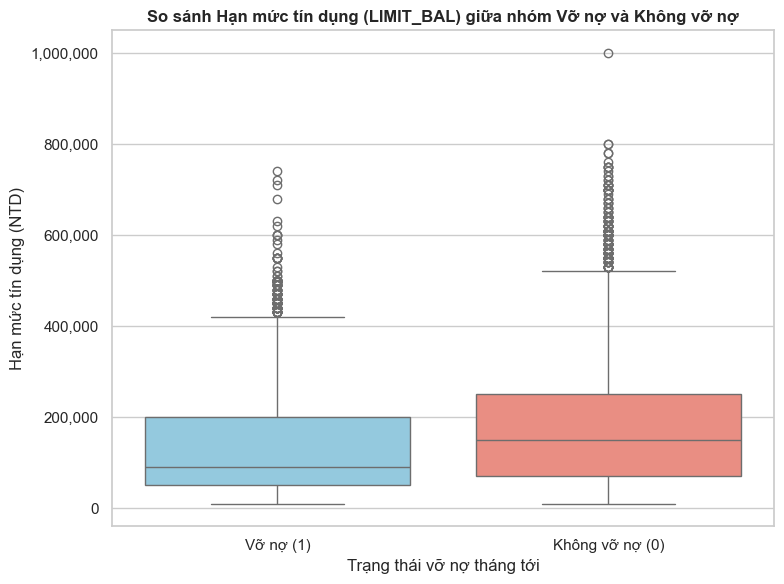

In [26]:
target = 'default.payment.next.month'
limit_bins = [0, 50000, 100000, 200000, np.inf]
limit_labels = ['< 50k', '50k-100k', '100k-200k', '> 200k']

df['LIMIT_GROUP'] = pd.cut(
    df['LIMIT_BAL'], bins=limit_bins, labels=limit_labels, right=False
)

limit_analysis = (
    df.groupby('LIMIT_GROUP', observed=False)[target]
    .agg(
        Tong_KH='count',
        So_KH_Vo_No='sum',
        Default_Rate_Pct=lambda x: round(x.mean() * 100, 2),
    )
    .reset_index()
)
print(limit_analysis)

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(8, 6))

df['TARGET_LABEL'] = df[target].map(
    {0: 'Không vỡ nợ (0)', 1: 'Vỡ nợ (1)'}
)

sns.boxplot(
    data=df,
    x='TARGET_LABEL',
    y='LIMIT_BAL',
    palette=['skyblue', 'salmon'],
    ax=ax,
    hue='TARGET_LABEL',
)

ax.set_title(
    'So sánh Hạn mức tín dụng (LIMIT_BAL) giữa nhóm Vỡ nợ và Không vỡ nợ',
    fontsize=12,
    fontweight='bold',
)
ax.set_xlabel('Trạng thái vỡ nợ tháng tới')
ax.set_ylabel('Hạn mức tín dụng (NTD)')

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'{int(x):,}')
)

plt.tight_layout()
plt.show()

**So sánh các chỉ số vị trí (Central Tendency & Dispersion)**

`Giá trị Trung vị (Median - Đường gạch ngang giữa hộp)`:
Nhóm Vỡ nợ (1): Trung vị hạn mức nằm ở mức thấp, khoảng 90,000 NTD.
Nhóm Không vỡ nợ (0): Trung vị hạn mức cao hơn rõ rệt, rơi vào khoảng 150,000 NTD.

`Khoảng tứ phân vị (IQR - Độ rộng của hộp đại diện cho 50% dữ liệu trung tâm):`
Nhóm Vỡ nợ (1): Hộp nằm lệch hẳn xuống phía dưới (khoảng từ 50,000 đến 200,000 NTD). Điều này cho thấy 50% khách hàng bị vỡ nợ tập trung chủ yếu ở phân khúc hạn mức nhỏ.
Nhóm Không vỡ nợ (0): Hộp nằm ở vùng cao hơn hẳn (khoảng từ 70,000 đến 250,000 NTD), thể hiện phân bố hạn mức của nhóm này dời sang mức tài chính tốt hơn.

**So sánh Giá trị ngoại lệ (Outliers)**

Nhóm Không vỡ nợ (0): Dải Outliers kéo dài lên rất cao, đạt mốc tối đa là 1,000,000 NTD. Các điểm ngoaị lệ tập trung dày đặc từ mức $520,000$ NTD trở lên.
Nhóm Vỡ nợ (1): Mức hạn mức tối đa của nhóm vỡ nợ thấp hơn nhiều (chỉ chạm ngưỡng khoảng 740,000 NTD) và số lượng điểm Outliers thưa thớt hơn hẳn.

**Ý nghĩa Nghiệp vụ & Hàm ý Rủi ro (Business & Risk Insights)**

`Mối tương quan nghịch giữa Hạn mức và Rủi ro vỡ nợ:`Khách hàng được cấp hạn mức tín dụng thấp có nguy cơ vỡ nợ cao hơn hẳn.Nguyên nhân là do các thuật toán thẩm định của ngân hàng thường cấp hạn mức thấp cho những khách hàng có thu nhập thấp, lịch sử tín dụng mỏng hoặc tài chính kém ổn định. Do đó, nhóm này có khả năng chống chịu rủi ro tài chính kém hơn khi gặp biến cố.
`Hiệu quả của bước Sàng lọc rủi ro (Credit Underwriting):`Việc nhóm "Không vỡ nợ" sở hữu hạn mức cao hơn hẳn và chiếm lĩnh các mốc cực đại ($1$ triệu NTD) chứng tỏ chính sách thẩm định của ngân hàng bước đầu đã phân loại tương đối tốt: Những khách hàng được duyệt hạn mức siêu cao thường là nhóm VIP có năng lực tài chính mạnh và tỷ lệ tuân thủ trả nợ rất tốt.

In [27]:
pay0_raw_df = (
    df.groupby('PAY_0')[target]
    .agg(
        Tong_KH='count',
        So_KH_Vo_No='sum',
        Default_Rate_Pct=lambda x: round(x.mean() * 100, 2),
    )
    .reset_index()
)

pay_group_cols = [f'{col}_GROUP' for col in pay_cols]
df['HAS_DELAY_2PLUS'] = (df[pay_group_cols] == 2).any(axis=1).astype(int)

risk_df = (
    df.groupby('HAS_DELAY_2PLUS')[target]
    .agg(
        Tong_KH='count',
        So_KH_Vo_No='sum',
        Default_Rate_Pct=lambda x: round(x.mean() * 100, 2),
    )
    .reset_index()
)

rate_0 = risk_df.loc[
    risk_df['HAS_DELAY_2PLUS'] == 0, 'Default_Rate_Pct'
].values[0]
rate_1 = risk_df.loc[
    risk_df['HAS_DELAY_2PLUS'] == 1, 'Default_Rate_Pct'
].values[0]
risk_ratio = round(rate_1 / rate_0, 2)

print(pay0_raw_df)
print(risk_df)
print(f'Risk_Ratio = {risk_ratio}')

    PAY_0  Tong_KH  So_KH_Vo_No  Default_Rate_Pct
0      -2     2759          365             13.23
1      -1     5686          954             16.78
2       0    14737         1888             12.81
3       1     3688         1252             33.95
4       2     2667         1844             69.14
5       3      322          244             75.78
6       4       76           52             68.42
7       5       26           13             50.00
8       6       11            6             54.55
9       7        9            7             77.78
10      8       19           11             57.89
   HAS_DELAY_2PLUS  Tong_KH  So_KH_Vo_No  Default_Rate_Pct
0                0    21620         2756             12.75
1                1     8380         3880             46.30
Risk_Ratio = 3.63


**Phân tích Lịch sử thanh toán tháng gần nhất (PAY_0)**

Nhóm đúng hạn / không dùng thẻ (-2, -1, 0): Tỷ lệ vỡ nợ thấp và an toàn, dao động từ $12.81\%$ đến $16.78\%$ (chiếm đa số mẫu với hơn 23,000 khách hàng).

Mốc trễ 1 tháng (PAY_0 = 1): Tỷ lệ vỡ nợ tăng gấp $2.65$ lần, từ $12.81\%$ lên $33.95\%$ $\rightarrow$ Dấu hiệu cảnh báo sớm về rủi ro dòng tiền.

Mốc trễ từ 2 tháng trở lên (PAY_0 \ge 2): Tỷ lệ vỡ nợ tăng vọt lên $69.14\%$ ngay tại mốc 2 tháng và duy trì ở mức rất cao ($50.00\% - 77.78\%$) ở các tháng sau $\rightarrow$ Ranh giới nợ xấu rõ rệt.

**Phân tích Biến cờ trễ hạn nặng (HAS_DELAY_2PLUS)**

Nhóm không trễ $\ge 2$ tháng (0): Tỷ lệ vỡ nợ chỉ $12.75\%$.

Nhóm từng trễ $\ge 2$ tháng (1): Tỷ lệ vỡ nợ tăng vọt lên $46.30\%$ (chênh lệch $33.55\%$).Risk Ratio = $3.63$: Khách hàng từng trễ hạn từ 2 tháng trở lên trong 6 tháng gần nhất có nguy cơ vỡ nợ cao gấp $3.63$ lần so với nhóm còn lại.

In [28]:
df['CREDIT_UTILIZATION'] = df['BILL_AMT1'] / df['LIMIT_BAL']
util_bins = [-np.inf, 0, 0.3, 0.7, 1.0, np.inf]
util_labels = ['< 0', '0 - 0.3', '0.3 - 0.7', '0.7 - 1.0', '> 1.0']
df['UTIL_GROUP'] = pd.cut(
    df['CREDIT_UTILIZATION'],
    bins=util_bins,
    labels=util_labels,
    right=False,
)

util_df = (
    df.groupby('UTIL_GROUP', observed=False)[target]
    .agg(
        Tong_KH='count',
        So_KH_Vo_No='sum',
        Default_Rate_Pct=lambda x: round(x.mean() * 100, 2),
    )
    .reset_index()
)

df['PAYMENT_RATIO'] = np.where(
    df['BILL_AMT2'] <= 0, 1.0, df['PAY_AMT1'] / df['BILL_AMT2']
)
pay_ratio_bins = [-np.inf, 0.05, 0.2, 0.8, np.inf]
pay_ratio_labels = ['< 0.05', '0.05 - 0.2', '0.2 - 0.8', '>= 0.8']
df['PAY_RATIO_GROUP'] = pd.cut(
    df['PAYMENT_RATIO'],
    bins=pay_ratio_bins,
    labels=pay_ratio_labels,
    right=False,
)

pay_ratio_df = (
    df.groupby('PAY_RATIO_GROUP', observed=False)[target]
    .agg(
        Tong_KH='count',
        So_KH_Vo_No='sum',
        Default_Rate_Pct=lambda x: round(x.mean() * 100, 2),
    )
    .reset_index()
)

print(util_df)
print(pay_ratio_df)

  UTIL_GROUP  Tong_KH  So_KH_Vo_No  Default_Rate_Pct
0        < 0      590          109             18.47
1    0 - 0.3    14202         2599             18.30
2  0.3 - 0.7     5686         1365             24.01
3  0.7 - 1.0     7399         1925             26.02
4      > 1.0     2123          638             30.05
  PAY_RATIO_GROUP  Tong_KH  So_KH_Vo_No  Default_Rate_Pct
0          < 0.05     9664         2696             27.90
1      0.05 - 0.2     7911         1800             22.75
2       0.2 - 0.8     2158          408             18.91
3          >= 0.8    10267         1732             16.87


### **EDA Summary**

**Mối liên hệ Nhân khẩu học: Nhóm tuổi nào có tỷ lệ nợ xấu cao nhất? Trình độ học vấn (Đại học vs Thạc sĩ vs Phổ thông) ảnh hưởng thế nào đến rủi ro?**
- Nhóm tuổi từ 60+ thuộc nhóm tuổi già có tỉ lệ nợ xấu cao nhất có thể suy ra từ vị trí và trạng thái nghề nghiệp, có thể do không quá chủ động được tài chính và thu nhập khi về già 
- Trình độ học vấn càng cao thường gắn liền với thu nhập ổn định và nhận thức quản lý tài chính cá nhân tốt hơn, từ đó làm giảm thiểu rủi ro vỡ nợ tín dụng.
  + Thạc sĩ/ Tiến sĩ có tỉ lệ vỡ nợ thấp nhất ($19.23\%$)
  + Đại học (2): Tỷ lệ vỡ nợ ở mức trung bình ($23.73\%$).
  + Phổ thông (3): Tỷ lệ vỡ nợ cao nhất trong 3 nhóm chính ($25.16\%$).


**Lịch sử trễ hạn (Pay Delinquency): Khách hàng từng trễ hạn $\ge 2$ tháng trong quá khứ có xác suất vỡ nợ tháng tới cao gấp bao nhiêu lần nhóm trả đúng hạn?**
Khách hàng từng có lịch sử trễ hạn từ $2$ tháng trở lên trong quá khứ có xác suất vỡ nợ vào tháng tới cao gấp $3.63$ lần so với nhóm không có lịch sử trễ hạn nặng.

**Hạn mức tín dụng vs Rủi ro: Nhóm được cấp hạn mức thấp (< 50.000 NTD) có tỷ lệ default cao hơn nhóm hạn mức cao không?**

Chênh lệch rủi ro: Khách hàng được cấp hạn mức < 50.000 NTD có nguy cơ vỡ nợ cao gấp 2.38 lần ($36.07\% / 15.13\%$) so với nhóm hạn mức cao (> 200.000 NTD).

Quy luật chung: Tỷ lệ vỡ nợ và hạn mức tín dụng có mối quan hệ tỷ lệ nghịch tuyệt đối — Hạn mức được cấp càng cao thì tỷ lệ vỡ nợ càng giảm dần đều ($36.07\% \rightarrow 26.01\% \rightarrow 20.77\% \rightarrow 15.13\%$).

### **Feature Engineering**

In [29]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['MAX_DELINQUENCY'] = df[pay_cols].max(axis=1)

bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
df['AVG_BILL_AMT'] = df[bill_cols].mean(axis=1)
df['BILL_TREND_RATIO'] = np.where(
    df['AVG_BILL_AMT'] <= 0, 1.0, df['BILL_AMT1'] / df['AVG_BILL_AMT']
)

print(
    df[[
        'CREDIT_UTILIZATION',
        'PAYMENT_RATIO',
        'MAX_DELINQUENCY',
        'BILL_TREND_RATIO',
    ]].head()
)

   CREDIT_UTILIZATION  PAYMENT_RATIO  MAX_DELINQUENCY  BILL_TREND_RATIO
0            0.195650       0.000000                2          3.047508
1            0.022350       0.000000                2          0.942320
2            0.324878       0.108220                0          1.725812
3            0.939800       0.041465                0          1.218757
4            0.172340       0.352734                0          0.472860


In [30]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['DELINQUENT_MONTHS_COUNT'] = (df[pay_cols] > 0).sum(axis=1)

df['BILL_DIFF_M1_M2'] = df['BILL_AMT1'] - df['BILL_AMT2']
df['BILL_DIFF_TOTAL_6M'] = df['BILL_AMT1'] - df['BILL_AMT6']

pay_amt_cols = [f'PAY_AMT{i}' for i in range(1, 7)]
bill_amt_cols = [f'BILL_AMT{i}' for i in range(1, 7)]

total_pay_6m = df[pay_amt_cols].sum(axis=1)
total_bill_6m = df[bill_amt_cols].sum(axis=1)

df['AVG_PAYMENT_RATIO_6M'] = np.where(total_bill_6m <= 0, 1.0, total_pay_6m / total_bill_6m)

In [31]:
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,UTIL_GROUP,PAYMENT_RATIO,PAY_RATIO_GROUP,MAX_DELINQUENCY,AVG_BILL_AMT,BILL_TREND_RATIO,DELINQUENT_MONTHS_COUNT,BILL_DIFF_M1_M2,BILL_DIFF_TOTAL_6M,AVG_PAYMENT_RATIO_6M
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0 - 0.3,0.000000,< 0.05,2,1284.000000,3.047508,2,811.0,3913.0,0.089434
1,2,120000.0,2,2,2,26,-1,2,0,0,...,0 - 0.3,0.000000,< 0.05,2,2846.166667,0.942320,2,957.0,-579.0,0.292791
2,3,90000.0,2,2,2,34,0,0,0,0,...,0.3 - 0.7,0.108220,0.05 - 0.2,0,16942.166667,1.725812,0,15212.0,13690.0,0.108388
3,4,50000.0,2,2,1,37,0,0,0,0,...,0.7 - 1.0,0.041465,< 0.05,0,38555.666667,1.218757,0,-1243.0,17443.0,0.036259
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,0 - 0.3,0.352734,0.2 - 0.8,0,18223.166667,0.472860,0,2947.0,-10514.0,0.540054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,0.7 - 1.0,0.044084,< 0.05,0,120891.500000,1.562955,0,-3867.0,172968.0,0.058661
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,0 - 0.3,1.004923,>= 0.8,0,3530.333333,0.476726,0,-145.0,1683.0,0.684071
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,0 - 0.3,0.000000,< 0.05,4,11749.333333,0.303421,3,209.0,-15792.0,0.443997
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,< 0,1.095957,>= 0.8,1,44435.166667,-0.037020,1,-80024.0,-50589.0,0.552044


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

### **Model Training**

In [33]:
!pip install xgboost lightgbm


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import sklearn as skt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, classification_report, f1_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [35]:
target = 'default.payment.next.month'

X = df.drop(columns=[target])
y = df[target]

In [36]:
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,UTIL_GROUP,PAYMENT_RATIO,PAY_RATIO_GROUP,MAX_DELINQUENCY,AVG_BILL_AMT,BILL_TREND_RATIO,DELINQUENT_MONTHS_COUNT,BILL_DIFF_M1_M2,BILL_DIFF_TOTAL_6M,AVG_PAYMENT_RATIO_6M
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0 - 0.3,0.000000,< 0.05,2,1284.000000,3.047508,2,811.0,3913.0,0.089434
1,2,120000.0,2,2,2,26,-1,2,0,0,...,0 - 0.3,0.000000,< 0.05,2,2846.166667,0.942320,2,957.0,-579.0,0.292791
2,3,90000.0,2,2,2,34,0,0,0,0,...,0.3 - 0.7,0.108220,0.05 - 0.2,0,16942.166667,1.725812,0,15212.0,13690.0,0.108388
3,4,50000.0,2,2,1,37,0,0,0,0,...,0.7 - 1.0,0.041465,< 0.05,0,38555.666667,1.218757,0,-1243.0,17443.0,0.036259
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,0 - 0.3,0.352734,0.2 - 0.8,0,18223.166667,0.472860,0,2947.0,-10514.0,0.540054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,0.7 - 1.0,0.044084,< 0.05,0,120891.500000,1.562955,0,-3867.0,172968.0,0.058661
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,0 - 0.3,1.004923,>= 0.8,0,3530.333333,0.476726,0,-145.0,1683.0,0.684071
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,0 - 0.3,0.000000,< 0.05,4,11749.333333,0.303421,3,209.0,-15792.0,0.443997
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,< 0,1.095957,>= 0.8,1,44435.166667,-0.037020,1,-80024.0,-50589.0,0.552044


In [37]:
df['flag_marriage_single'] = (df['MARRIAGE'] == 2).astype(int)
df['flag_marriage_others'] = (~df['MARRIAGE'].isin([1, 2])).astype(int)

df['flag_edu_university'] = (df['EDUCATION'] == 2).astype(int)
df['flag_edu_high_school'] = (df['EDUCATION'] == 3).astype(int)
df['flag_edu_others'] = (~df['EDUCATION'].isin([1, 2, 3])).astype(int)

df['flag_sex_female'] = (df['SEX'] == 2).astype(int)

df = df.drop(columns=['SEX', 'EDUCATION', 'MARRIAGE'])

df.head()

,ID,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,DELINQUENT_MONTHS_COUNT,BILL_DIFF_M1_M2,BILL_DIFF_TOTAL_6M,AVG_PAYMENT_RATIO_6M,flag_marriage_single,flag_marriage_others,flag_edu_university,flag_edu_high_school,flag_edu_others,flag_sex_female
0,1,20000.0,24,2,2,-1,-1,-2,-2,3913.0,...,2,811.0,3913.0,0.089434,0,0,1,0,0,1
1,2,120000.0,26,-1,2,0,0,0,2,2682.0,...,2,957.0,-579.0,0.292791,1,0,1,0,0,1
2,3,90000.0,34,0,0,0,0,0,0,29239.0,...,0,15212.0,13690.0,0.108388,1,0,1,0,0,1
3,4,50000.0,37,0,0,0,0,0,0,46990.0,...,0,-1243.0,17443.0,0.036259,0,0,1,0,0,1
4,5,50000.0,57,-1,0,-1,0,0,0,8617.0,...,0,2947.0,-10514.0,0.540054,0,0,1,0,0,0


In [38]:
model_features = [
    'PAY_0', 'DELINQUENT_MONTHS_COUNT', 'MAX_DELINQUENCY',
    'LIMIT_BAL', 'CREDIT_UTILIZATION', 'PAY_AMT1', 'AVG_PAYMENT_RATIO_6M',
    'AVG_BILL_AMT', 'BILL_DIFF_M1_M2',
    'AGE', 'flag_sex_female',
    'flag_marriage_single', 'flag_marriage_others',
    'flag_edu_university', 'flag_edu_high_school', 'flag_edu_others'
]

y = df['default.payment.next.month']
X = df[model_features].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [39]:
log_cols = ['LIMIT_BAL', 'PAY_AMT1', 'AVG_PAYMENT_RATIO_6M']
for col in log_cols:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])
scaler = StandardScaler()

scale_cols = ['LIMIT_BAL', 'PAY_AMT1', 'AVG_PAYMENT_RATIO_6M', 'AVG_BILL_AMT', 'BILL_DIFF_M1_M2', 'AGE']

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [40]:
corr_features = [
    'LIMIT_BAL', 'AGE', 'PAY_0', 'DELINQUENT_MONTHS_COUNT', 'MAX_DELINQUENCY',
    'CREDIT_UTILIZATION', 'PAY_AMT1', 'AVG_PAYMENT_RATIO_6M',
    'AVG_BILL_AMT', 'BILL_DIFF_M1_M2', 'default.payment.next.month'
]

cor_matrix = df[corr_features].corr(method='pearson')
print(cor_matrix)

                            LIMIT_BAL       AGE     PAY_0  \
LIMIT_BAL                    1.000000  0.144713 -0.271214   
AGE                          0.144713  1.000000 -0.039447   
PAY_0                       -0.271214 -0.039447  1.000000   
DELINQUENT_MONTHS_COUNT     -0.236763 -0.015356  0.635398   
MAX_DELINQUENCY             -0.294486 -0.049913  0.765436   
CREDIT_UTILIZATION          -0.369990 -0.026955  0.384327   
PAY_AMT1                     0.195236  0.026147 -0.079269   
AVG_PAYMENT_RATIO_6M         0.043871  0.004214 -0.045429   
AVG_BILL_AMT                 0.302044  0.054981  0.191803   
BILL_DIFF_M1_M2              0.053304  0.012239  0.011548   
default.payment.next.month  -0.153520  0.013890  0.324794   

                            DELINQUENT_MONTHS_COUNT  MAX_DELINQUENCY  \
LIMIT_BAL                                 -0.236763        -0.294486   
AGE                                       -0.015356        -0.049913   
PAY_0                                      0.635398

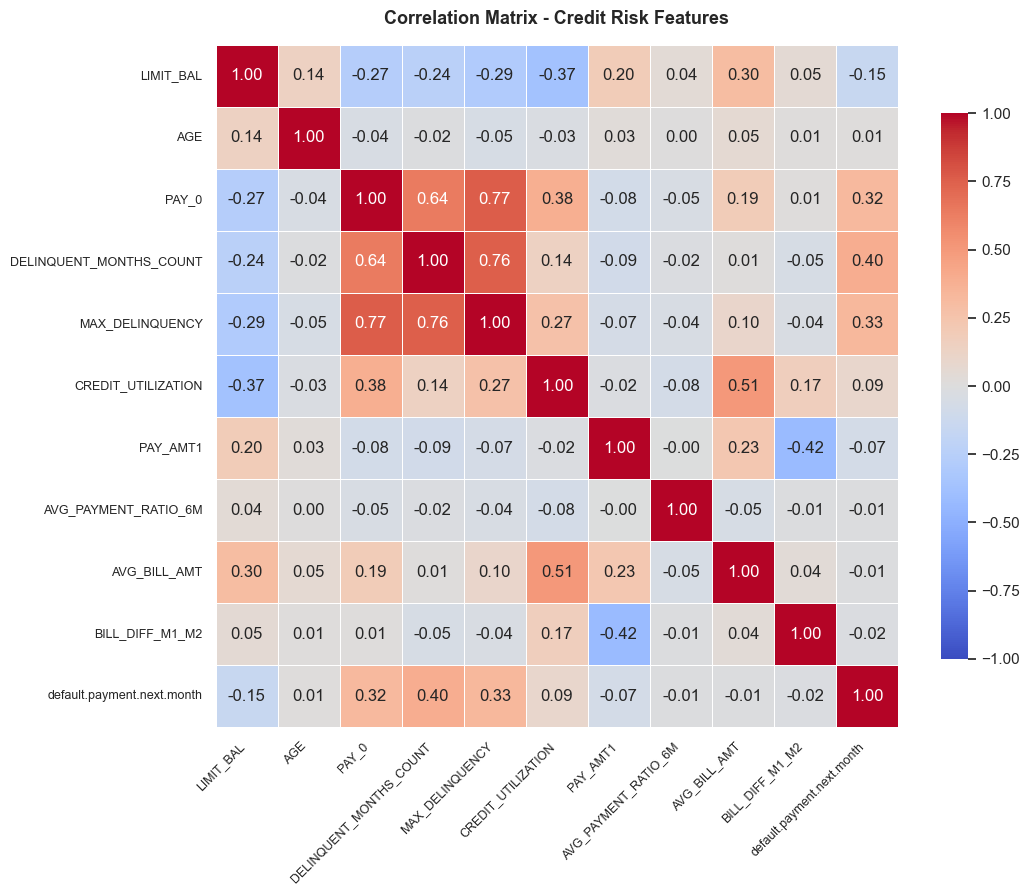

In [41]:
plt.figure(figsize=(11, 9))
sns.heatmap(
    cor_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix - Credit Risk Features", fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

Nhóm tương quan thuận mạnh nhất với nợ xấu (default): DELINQUENT_MONTHS_COUNT ($0.40$), MAX_DELINQUENCY ($0.33$), và PAY_0 ($0.32$) — đây là các đặc trưng quan trọng nhất.Đa cộng tuyến giữa các biến trễ hạn: Cả 3 biến trễ hạn đều có tương quan chéo với nhau quanh mức $0.64 - 0.77$.

 Với mô hình Tree-based (Random Forest / XGBoost), sự đa cộng tuyến này không gây ảnh hưởng tiêu cực, nhưng nếu dùng Logistic Regression thì cần lưu ý.

`*Note*`:

**Dữ liệu bị mất cân bằng (Imbalanced Data)**: Tỷ lệ giữa lớp đa số (0 - Không vỡ nợ) và lớp yếu tố rủi ro (1 - Vỡ nợ) rơi vào khoảng 3.5 : 1.

Mức độ mất cân bằng: Đây là mức độ mất cân bằng trung bình (Moderate Imbalance). Tỷ lệ 22% vỡ nợ thực tế là khá hợp lý và phản ánh đúng thực trạng rủi ro tín dụng thẻ trong ngành ngân hàng (không bị quá hiếm như các bài toán phát hiện gian lận giao dịch/fraud detection vốn chỉ chiếm < 1%).

Hoặc điều chỉnh tham số trong mô hình (ví dụ: gán class_weight='balanced' trong Logistic Regression, Random Forest, XGBoost).

Không dùng Accuracy (Độ chính xác): Chỉ số Accuracy sẽ bị vô hiệu hóa / đánh lừa trong bài toán này.

`Thay vào đó:`

Recall (Độ gợi nhớ): Đo lường xem mô hình bắt được bao nhiêu % trong số 6,636 người vỡ nợ thật. Trong ngân hàng, chỉ số này cực kỳ quan trọng vì thà bắt nhầm còn hơn bỏ sót nợ xấu (`Ưu tiên`)

Precision & F1-Score: Để đảm bảo sự cân bằng, không báo động giả quá nhiều.

ROC-AUC & PR-AUC: Thước đo tổng quát nhất để đánh giá khả năng phân loại rủi ro của mô hình trên dữ liệu mất cân bằng.

In [42]:
logit_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
logit_model.fit(X_train, y_train)

y_pred_proba = logit_model.predict_proba(X_test)[:, 1]
y_pred = logit_model.predict(X_test)

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}\n")
print(classification_report(y_test, y_pred))

coef_full_df = pd.DataFrame({
    'Feature': model_features,
    'Beta_Coefficient': logit_model.coef_[0]
}).sort_values(by='Beta_Coefficient', ascending=False)

print("\n--- BẢNG HỆ SỐ BETA---")
print(coef_full_df.to_string(index=False))

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


ROC-AUC Score: 0.7420

              precision    recall  f1-score   support

           0       0.87      0.80      0.83      4673
           1       0.46      0.59      0.52      1327

    accuracy                           0.75      6000
   macro avg       0.66      0.70      0.68      6000
weighted avg       0.78      0.75      0.76      6000


--- BẢNG HỆ SỐ BETA---
                Feature  Beta_Coefficient
DELINQUENT_MONTHS_COUNT          0.355344
                  PAY_0          0.229601
   AVG_PAYMENT_RATIO_6M          0.146190
     CREDIT_UTILIZATION          0.143923
        MAX_DELINQUENCY          0.077476
                    AGE          0.045122
           AVG_BILL_AMT          0.039861
    flag_edu_university         -0.006746
        BILL_DIFF_M1_M2         -0.018241
   flag_marriage_others         -0.078177
   flag_edu_high_school         -0.098165
        flag_sex_female         -0.115537
   flag_marriage_single         -0.166188
               PAY_AMT1         -0.207

In [43]:
refined_features = [f for f in model_features if f != 'MAX_DELINQUENCY']

X_train_refined = X_train[refined_features]
X_test_refined = X_test[refined_features]

logit_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
logit_model.fit(X_train_refined, y_train)

y_pred_proba = logit_model.predict_proba(X_test_refined)[:, 1]
y_pred = logit_model.predict(X_test_refined)

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}\n")
print(classification_report(y_test, y_pred))

coef_df = pd.DataFrame({
    'Feature': refined_features,
    'Beta_Coefficient': logit_model.coef_[0]
}).sort_values(by='Beta_Coefficient', ascending=False)

print("\n--- BẢNG HỆ SỐ BETA (LOG-ODDS) ---")
print(coef_df.to_string(index=False))

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


ROC-AUC Score: 0.7427

              precision    recall  f1-score   support

           0       0.87      0.81      0.84      4673
           1       0.46      0.58      0.52      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.78      0.76      0.77      6000


--- BẢNG HỆ SỐ BETA (LOG-ODDS) ---
                Feature  Beta_Coefficient
DELINQUENT_MONTHS_COUNT          0.388645
                  PAY_0          0.265714
   AVG_PAYMENT_RATIO_6M          0.137186
     CREDIT_UTILIZATION          0.128289
                    AGE          0.044143
           AVG_BILL_AMT          0.043945
    flag_edu_university         -0.007161
        BILL_DIFF_M1_M2         -0.018650
   flag_marriage_others         -0.071177
   flag_edu_high_school         -0.096633
        flag_sex_female         -0.117686
   flag_marriage_single         -0.163604
               PAY_AMT1         -0.207950
              LIMIT_BAL   

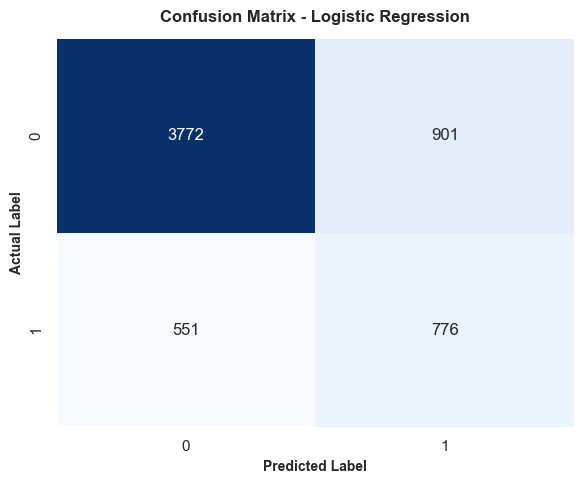

In [44]:
y_pred_logit = logit_model.predict(X_test[refined_features])
cm = confusion_matrix(y_test, y_pred_logit)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1'],
    cbar=False
)

plt.title('Confusion Matrix - Logistic Regression', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Predicted Label', fontsize=10, fontweight='bold')
plt.ylabel('Actual Label', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

Nhận xét chuyên sâu về Mô hình Logistic Regression (Sau khi loại bỏ MAX_DELINQUENCY):

**Hiệu năng tổng thể & Khả năng phân loại (Classification Performance)**

ROC-AUC đạt 0.7427: Mô hình duy trì khả năng phân biệt rủi ro ở mức khá tốt; tăng nhẹ so với mô hình gốc (0.7420), khẳng định việc cắt giảm biến dư thừa không làm tổn hại đến năng lực dự báo mà còn giảm nhiễu.

Recall nợ xấu (Class 1) = 0.58: Mô hình phát hiện được 58% hồ sơ thực tế có rủi ro vỡ nợ, đảm bảo mục tiêu an toàn vốn cho ngân hàng khi dùng kỹ thuật class_weight='balanced'.

Precision nợ xấu (Class 1) = 0.46: Độ chính xác cảnh báo đạt 46%, cao hơn gấp đôi so với tỷ lệ nợ xấu cơ sở trong tổng thể (~22%).

**Đóng góp & Ý nghĩa của các đặc trưng (Feature Importance via Log-Odds)**

Nhóm hành vi chi phối mạnh nhất (β>0):

DELINQUENT_MONTHS_COUNT (β=+0.3886) và PAY_0 (β=+0.2657) là hai nhân tố rủi ro hàng đầu. Việc loại bỏ MAX_DELINQUENCY đã giúp hai biến này hấp thụ trọn vẹn thông tin về tần suất vi phạm (Frequency) và trạng thái hiện tại (Recency) mà không còn bị phân mảnh trọng số.

AVG_PAYMENT_RATIO_6M (β=+0.1372) và CREDIT_UTILIZATION (β=+0.1283) tiếp tục phản ánh áp lực đòn bẩy và việc sử dụng cạn hạn mức thẻ làm tăng nguy cơ mất thanh khoản.

Nhóm kiểm soát & Giảm thiểu rủi ro (β<0):

LIMIT_BAL (β=−0.2448) và PAY_AMT1 (β=−0.2080) có trọng số âm mạnh nhất, chứng minh khách hàng có hạn mức cao hoặc thanh toán thực tế nhiều ở kỳ gần nhất có độ an toàn tài chính vượt trội.

Các biến nhân khẩu học (flag_marriage_single, flag_sex_female) có tác động giảm nhẹ rủi ro nợ xấu so với nhóm đối chứng.

**Đánh giá tính tối ưu kiến trúc (Parsimony)**
Mô hình thứ hai đáp ứng chuẩn mực Parsimonious Model trong quản trị rủi ro định lượng: cấu trúc gọn gàng hơn, triệt tiêu đa cộng tuyến giữa nhóm biến trễ hạn, giữ nguyên vẹn khả năng giải thích hệ số và tối ưu hóa tính khái quát hóa khi áp dụng vào dữ liệu mới.

In [45]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)

print("================ RANDOM FOREST ================")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf))

================ RANDOM FOREST ================
ROC-AUC Score: 0.7795

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4673
           1       0.45      0.62      0.52      1327

    accuracy                           0.75      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.79      0.75      0.76      6000



In [46]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

print("\n================ XGBOOST ================")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}\n")
print(classification_report(y_test, y_pred_xgb))

feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_Gain': xgb_model.feature_importances_
}).sort_values(by='Importance_Gain', ascending=False)

print("\n--- TOP ĐẶC TRƯNG QUAN TRỌNG NHẤT (XGBOOST) ---")
print(feat_imp.to_string(index=False))


================ XGBOOST ================
ROC-AUC Score: 0.7815

              precision    recall  f1-score   support

           0       0.89      0.79      0.84      4673
           1       0.47      0.64      0.54      1327

    accuracy                           0.76      6000
   macro avg       0.68      0.72      0.69      6000
weighted avg       0.79      0.76      0.77      6000


--- TOP ĐẶC TRƯNG QUAN TRỌNG NHẤT (XGBOOST) ---
                Feature  Importance_Gain
DELINQUENT_MONTHS_COUNT         0.342877
        MAX_DELINQUENCY         0.267617
                  PAY_0         0.167413
           AVG_BILL_AMT         0.026321
              LIMIT_BAL         0.025660
               PAY_AMT1         0.025405
     CREDIT_UTILIZATION         0.020982
   AVG_PAYMENT_RATIO_6M         0.017383
        flag_edu_others         0.017213
        BILL_DIFF_M1_M2         0.016805
   flag_marriage_single         0.015135
    flag_edu_university         0.014276
        flag_sex_female  